In [1]:
# Magics
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
# from pathlib import Path
# import os
# import numpy as np
# import pickle
import matplotlib.pyplot as plt
plt.style.use('default')  # Resets to standard white background
# from ephys.decoder import *
import seaborn as sns
sns.set_theme()
sns.set_style('ticks')
sns.set_context('talk')

# from ephys.preprocessing import get_behavior_id, preprocess
# from ephys.analysis import get_all_psth
# from parse.parse_v2 import parse_v2
from ephys.decoder import *

# Load data

## Load spike counts

In [3]:
subject = '007'
folder_parent = Path.home() / 'data' / subject

ephys_ids = [
    '007_2024-06-22_10-48-57',
    '007_2024-06-23_12-46-55',
    '007_2024-06-24_17-47-22',
    '007_2024-06-27_15-06-28',
    '007_2024-07-09_12-10-57',
    '007_2024-07-10_12-03-35',
    '007_2024-07-11_12-39-21',
    '007_2024-07-12_13-29-26'
]

# Load spike counts for all neurons of a session (bins, all_psth). If file doesn't exist, create it
for i in range(len(ephys_ids)):

    print(f'Processing session {i + 1}/{len(ephys_ids)}: {ephys_ids[i]}...')

    # Create child folder within parent folder for each ephys_id with its name if it doesn't exist
    folder_child = folder_parent / ephys_ids[i]
    folder_child.mkdir(parents=True, exist_ok=True)
    os.chdir(folder_child)

    # Execute only if folder is empty
    if len(os.listdir(folder_child)) > 0:
        print('Folder is not empty. Skipping...')
        continue
    else:
        print('Folder is empty. Proceeding...')
        df_ttl, df_behavior, n_trials, df_spikes, cluster_info, x, height, labels, y, width, left, ts_edges, events_edges = \
            preprocess(ephys_ids[i])
        bins, all_psth = get_all_psth(cluster_info, df_spikes, df_ttl, n_trials, time_win=[-1, 3], bin_size=0.1)

    # Save bins and psth
    np.save(folder_child / 'bins.npy', bins)
    np.save(folder_child / 'all_psth.npy', all_psth)

Processing session 1/8: 007_2024-06-22_10-48-57...
Folder is not empty. Skipping...
Processing session 2/8: 007_2024-06-23_12-46-55...
Folder is not empty. Skipping...
Processing session 3/8: 007_2024-06-24_17-47-22...
Folder is not empty. Skipping...
Processing session 4/8: 007_2024-06-27_15-06-28...
Folder is not empty. Skipping...
Processing session 5/8: 007_2024-07-09_12-10-57...
Folder is not empty. Skipping...
Processing session 6/8: 007_2024-07-10_12-03-35...
Folder is not empty. Skipping...
Processing session 7/8: 007_2024-07-11_12-39-21...
Folder is not empty. Skipping...
Processing session 8/8: 007_2024-07-12_13-29-26...
Folder is not empty. Skipping...


## Load behavior

In [4]:
%%time
# Load behavioral data from all sessions in a list of DataFrames
behavior = []
for _ in range(len(ephys_ids)):
    print(f'Parsing behavioral session {_ + 1}/{len(ephys_ids)}: {ephys_ids[_]}...')
    path_behavior = get_behavior_id(ephys_ids[_])
    df_behavior = parse_v2(path_behavior)
    behavior.append(df_behavior)

# Get behavioral events
stim_dur = df_behavior.StimDur.unique()[0]
delay = df_behavior.Delay.unique()[0]
go_cue = stim_dur + delay

Parsing behavioral session 1/8: 007_2024-06-22_10-48-57...
Parsing behavioral session 2/8: 007_2024-06-23_12-46-55...
Parsing behavioral session 3/8: 007_2024-06-24_17-47-22...
Parsing behavioral session 4/8: 007_2024-06-27_15-06-28...
Parsing behavioral session 5/8: 007_2024-07-09_12-10-57...
Parsing behavioral session 6/8: 007_2024-07-10_12-03-35...
Parsing behavioral session 7/8: 007_2024-07-11_12-39-21...
Parsing behavioral session 8/8: 007_2024-07-12_13-29-26...
CPU times: total: 28.2 s
Wall time: 29.1 s


# Within Temporal Decoder (mean)

In [6]:
%%time
# Run mean within decoder across sessions
# results = mean_within_decoder(save=True, plot=False)

In [5]:
# Load mean within decoder results across sessions
with open(Path(folder_parent / 'results_mean_within_decoder.pkl'), 'rb') as f:
    results = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n007, 8 sessions, 5050 trials')

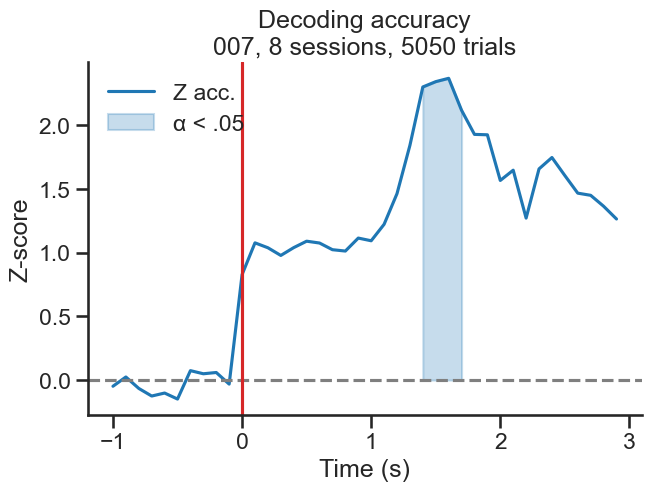

In [6]:
# Plot mean within decoder results across sessions
plot_mean_within_decoder(results, z_null=True)
# plt.axvline(go_cue, color='tab:gray', linestyle='-')  # Go cue
n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
plt.title(f"Decoding accuracy\n"
          f"{subject}, {len(results['acc'])} sessions, {n_trials} trials")

# Cross Temporal Decoder (mean)

In [9]:
%%time
# Run mean cross decoder across sessions
# results = mean_cross_decoder(save=True, plot=False)

In [7]:
# Load mean cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_cross_decoder.pkl'), 'rb') as f:
    results = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n 007, 8 sessions, 5050 trials')

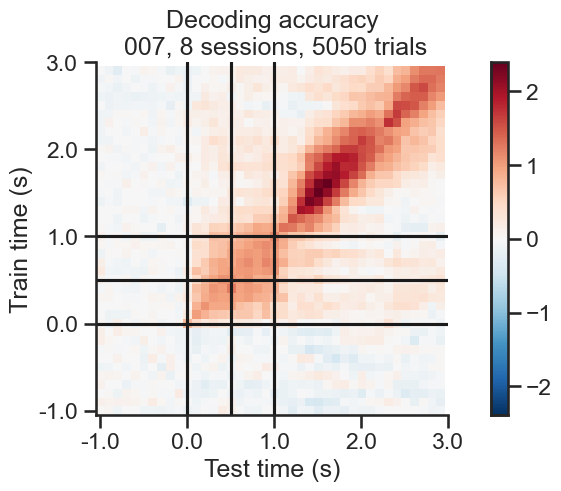

In [8]:
# Plot mean within decoder results across sessions
plot_mean_cross_decoder(results, z_null=True)
n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
plt.title(f"Decoding accuracy\n"
          f" {subject}, {len(results['acc'])} sessions, {n_trials} trials")

# Epoch Cross Temporal Decoder (mean)

In [ ]:
%%time
from ephys.decoder import *
# Run mean epoch cross decoder across sessions
results_stim = mean_epoch_cross_decoder(epoch='stim', save=False, plot=False)
# results_delay = mean_epoch_cross_decoder(epoch='delay', save=False, plot=False)
# results_resp = mean_epoch_cross_decoder(epoch='resp', save=False, plot=False)

Processing session 1/8: 007_2024-06-22_10-48-57...
epoch_cross_decoder took 1095.86 seconds to run
Processing session 2/8: 007_2024-06-23_12-46-55...
epoch_cross_decoder took 9.54 seconds to run
Processing session 3/8: 007_2024-06-24_17-47-22...


C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

epoch_cross_decoder took 10.18 seconds to run
Processing session 4/8: 007_2024-06-27_15-06-28...


C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

epoch_cross_decoder took 10.08 seconds to run
Processing session 5/8: 007_2024-07-09_12-10-57...


In [9]:
# Load mean epoch cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim.pkl'), 'rb') as f:
    results_stim = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay.pkl'), 'rb') as f:
    results_delay = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp.pkl'), 'rb') as f:
    results_resp = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n007, 8 sessions, 5050 trials')

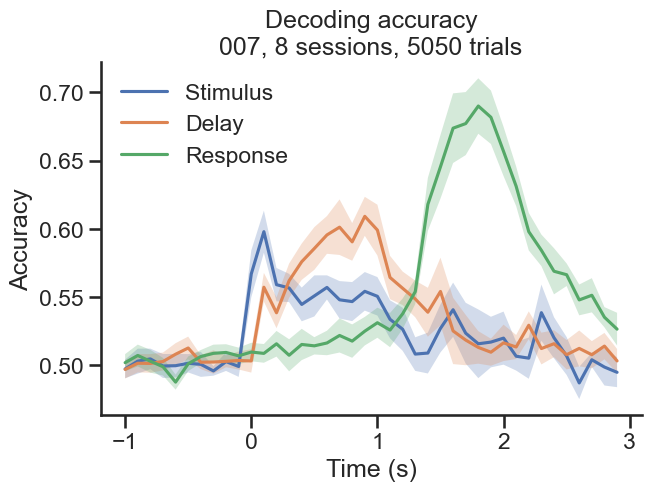

In [10]:
# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim, epoch='stim', z_null=False)
plot_mean_epoch_cross_decoder(results_delay, epoch='delay', z_null=False)
plot_mean_epoch_cross_decoder(results_resp, epoch='resp', z_null=False)
plt.title(f'Decoding accuracy\n'
          f'{subject}, {len(results["acc"])} sessions, {n_trials} trials')

# Epoch Cross Temporal Decoder Split (mean)

## Stimulus Code Split by Outcome (blue trace in previous plot)
2 approaches that should lead to the same result, but so far don't:
1. Run the epoch cross decoder function above for all trials and then average across trial types according to split (e.g. splitting by outcome in correct/error trials)
2. Run the epoch cross decoder **split** function that performs the split when training the decoder

### 1. Run epoch cross decoder function for all trials and average across trial types

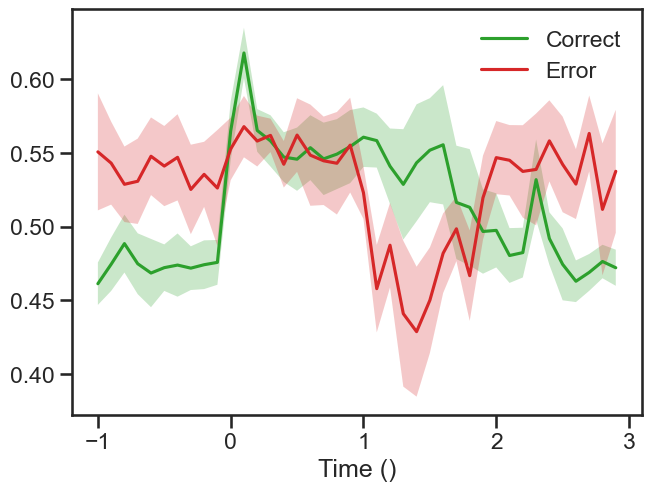

In [15]:
# Split stim decoder into correct vs error trials
indexes = [get_trial_indexes(behavior[i], condition='outcome') for i in range(len(behavior))]
# indexes = [get_trial_indexes(behavior[i][behavior[i].Miss==0].reset_index(drop=True), condition='outcome') for i in range(len(behavior))]

# Correct trials
mae_stim_correct = [-np.mean(np.abs(results_stim['pred_err'][i][indexes[i][1]]), axis=0) + 1 for i in range(len(results_stim['pred_err']))]
mae_stim_correct = np.array(mae_stim_correct)
avg_pred_err_null = [results_stim['pred_err_null'][i].mean(axis=2) for i in range(len(results_stim['pred_err_null']))]
mae_stim_correct_null = [-np.abs(avg_pred_err_null[i][indexes[i][1]]).mean(axis=0)+1 for i in range(len(results_stim['pred_err_null']))]
mae_stim_correct_null = np.array(mae_stim_correct_null)

# Error trials
mae_stim_error = [-np.mean(np.abs(results_stim['pred_err'][i][indexes[i][0]]), axis=0) + 1 for i in range(len(results_stim['pred_err']))]
mae_stim_error = np.array(mae_stim_error)
avg_pred_err_null = [results_stim['pred_err_null'][i].mean(axis=2) for i in range(len(results_stim['pred_err_null']))]
mae_stim_error_null = [-np.abs(avg_pred_err_null[i][indexes[i][0]]).mean(axis=0)+1 for i in range(len(results_stim['pred_err_null']))]
mae_stim_error_null = np.array(mae_stim_error_null)

plt.figure(constrained_layout=True)
color = 'tab:green'
plt.plot(results_stim['bins'][:-1], mae_stim_correct.mean(axis=0), color=color, label='Correct')
plt.fill_between(results_stim['bins'][:-1], mae_stim_correct.mean(axis=0) - sem(mae_stim_correct, axis=0),
                 mae_stim_correct.mean(axis=0) + sem(mae_stim_correct, axis=0), color=color, edgecolor='none',
                 alpha=0.25)
color = 'tab:red'
plt.plot(results_stim['bins'][:-1], mae_stim_error.mean(axis=0), color=color, label='Error')
plt.fill_between(results_stim['bins'][:-1], mae_stim_error.mean(axis=0) - sem(mae_stim_error, axis=0),
                 mae_stim_error.mean(axis=0) + sem(mae_stim_error, axis=0), color=color, edgecolor='none',
                 alpha=0.25)
plt.xlabel('Time ()')
plt.legend(frameon=False)


### 2. Run epoch cross decoder **split** function that performs the split when training the decoder

In [5]:
%%time
from ephys.decoder import *
# Run mean epoch cross decoder split across sessions
results = mean_epoch_cross_decoder_split(epoch='stim', split_by='Hit', save=False, plot=False)

Processing session 1/8: 007_2024-06-22_10-48-57...
epoch_cross_decoder_split took 8.55 seconds to run
Processing session 2/8: 007_2024-06-23_12-46-55...
epoch_cross_decoder_split took 8.49 seconds to run
Processing session 3/8: 007_2024-06-24_17-47-22...


C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

epoch_cross_decoder_split took 8.69 seconds to run
Processing session 4/8: 007_2024-06-27_15-06-28...


C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Usuario\anaconda3\envs\PycharmProjects\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/l

epoch_cross_decoder_split took 8.57 seconds to run
Processing session 5/8: 007_2024-07-09_12-10-57...
epoch_cross_decoder_split took 8.41 seconds to run
Processing session 6/8: 007_2024-07-10_12-03-35...
epoch_cross_decoder_split took 8.28 seconds to run
Processing session 7/8: 007_2024-07-11_12-39-21...
epoch_cross_decoder_split took 8.30 seconds to run
Processing session 8/8: 007_2024-07-12_13-29-26...
epoch_cross_decoder_split took 8.39 seconds to run
CPU times: total: 7min 15s
Wall time: 1min 36s


In [12]:
# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_split_stim_split_by_Hit.pkl'), 'rb') as f:
    results = pickle.load(f)

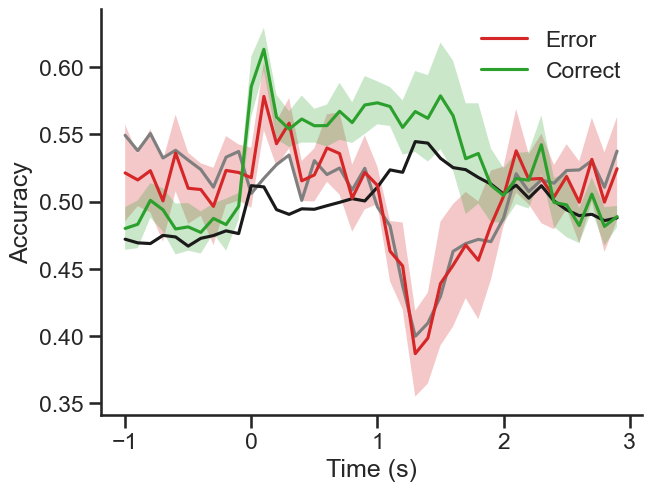

In [8]:
# plot mean NEGATIVE MEAN ABS + 1 PRED ERROR epoch decoder split by Hit
plt.figure(constrained_layout=True)
y_error_mean = -np.mean([np.nanmean(np.abs(results['pred_err0'][i]), axis=0) for i in range(len(results["pred_err0"]))], axis=0) + 1
y_correct_mean = -np.mean([np.nanmean(np.abs(results['pred_err1'][i]), axis=0) for i in range(len(results["pred_err1"]))], axis=0) + 1

y_error_null = -np.mean([np.nanmean(np.abs(np.nanmean(results['pred_err_null0'][i], axis=2)), axis=0)
                         for i in range(len(results["pred_err_null0"]))], axis=0) + 1
y_correct_null = -np.mean([np.nanmean(np.abs(np.nanmean(results['pred_err_null1'][i], axis=2)), axis=0)
                         for i in range(len(results["pred_err_null1"]))], axis=0) + 1

plt.plot(results['bins'][:-1], y_error_null, color='tab:gray')
plt.plot(results['bins'][:-1], y_correct_null, color='k')


y_error_sem = sem([np.nanmean(np.abs(results['pred_err0'][i]), axis=0) for i in range(len(results["pred_err0"]))], axis=0)
y_correct_sem = sem([np.nanmean(np.abs(results['pred_err1'][i]), axis=0) for i in range(len(results["pred_err1"]))], axis=0)
plt.plot(results['bins'][:-1], y_error_mean, color='tab:red', label='Error')
plt.fill_between(results['bins'][:-1], y_error_mean - y_error_sem, y_error_mean + y_error_sem, color='tab:red', edgecolor='none', alpha=0.25)
plt.plot(results['bins'][:-1], y_correct_mean, color='tab:green', label='Correct')
plt.fill_between(results['bins'][:-1], y_correct_mean - y_correct_sem, y_correct_mean + y_correct_sem, color='tab:green', edgecolor='none', alpha=0.25)
plt.xlabel('Time (s)')
plt.ylabel('Accuracy')
# n_trials = np.sum([results['apred_err'][i].shape[0] for i in range(len(results['acc']))])
plt.legend(frameon=False)
# plt.title(f'Decoding accuracy\n'
#           f'{subject}, {len(results["acc"])} sessions, {n_trials} trials')
# plt.title('Epoch cross decoder split by Hit')
sns.despine()



# Comment the plot
For error trials (red) the shuffles follow the downward trend of the code because in every erro trial the animal licked to the opposite side of stimulus (what I am decoding)
What is more weird is that there's also a lot of code in correct trials's shuffles. It could be a bias

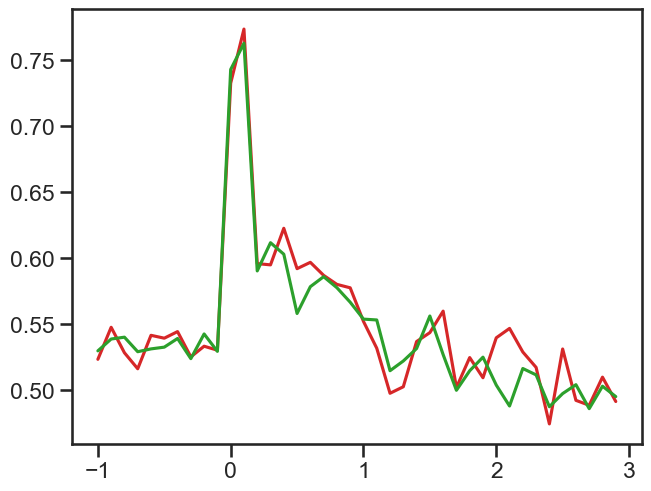

In [14]:
# plot mean ACCURACY epoch decoder split by Hit
plt.figure(constrained_layout=True)
plt.plot(results['bins'][:-1], np.nanmean([np.nanmean(results['acc0'][i], axis=0) for i in range(len(results["acc0"]))], axis=0), color='tab:red', label='Error')
plt.plot(results['bins'][:-1], np.nanmean([np.nanmean(results['acc1'][i], axis=0) for i in range(len(results["acc1"]))], axis=0), color='tab:green', label='Correct')

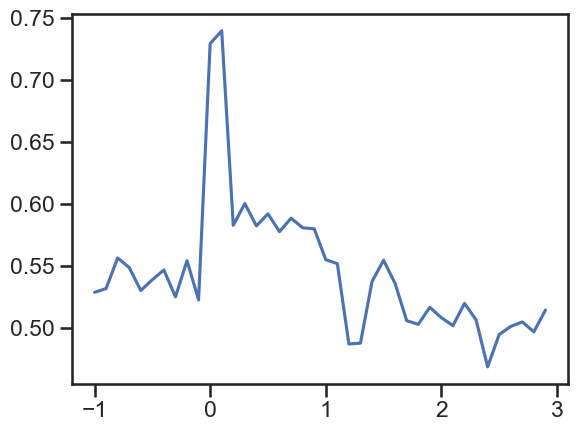

In [24]:
# Create a new test variable that for every session concatenates pred_err0 and pred_err1
test = [np.concatenate((results['pred_err0'][i], results['pred_err1'][i]), axis=0) for i in range(len(results['pred_err0']))]
# Take mean of test for every session
test = -np.nanmean([np.nanmean(np.abs(test[i]), axis=0) for i in range(len(test))], axis=0) + 1
plt.plot(results['bins'][:-1], test)

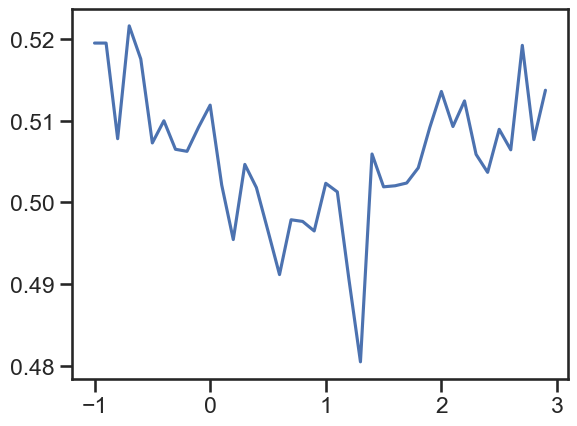

In [26]:
# Create a new test variable that for every session concatenates pred_err0 and pred_err1
test = [np.concatenate((results['pred_err_null0'][i], results['pred_err_null1'][i]), axis=0) for i in range(len(results['pred_err0']))]
# Take mean of test for every session
test = -np.nanmean([np.nanmean(np.abs(test[i]), axis=(0, 2)) for i in range(len(test))], axis=0) + 1
plt.plot(results['bins'][:-1], test)

# Plotting mean epoch decoder split by Hit from results of cross_decoder

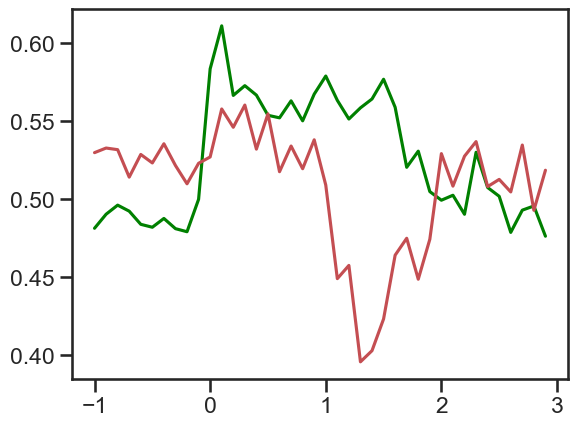

In [7]:
behavior = [behavior[i][behavior[i].Miss==0].reset_index(drop=True) for i in range(len(behavior))]

hits = [np.where(behavior[i].Hit == True)[0] for i in range(len(behavior))]
errors = [np.where(behavior[i].Hit == False)[0] for i in range(len(behavior))]
misses = [np.where(np.isnan(behavior[i].Hit))[0] for i in range(len(behavior))]

hit_stim_correct = np.array([-np.mean(np.abs(results_stim['pred_err'][i][hits[i]]), axis=0) + 1 for i in range(len(results_stim['pred_err']))])

errors_stim_correct = np.array([-np.mean(np.abs(results_stim['pred_err'][i][errors[i]]), axis=0) + 1 for i in range(len(results_stim['pred_err']))])

misses_stim_correct = np.array([-np.mean(np.abs(results_stim['pred_err'][i][misses[i]]), axis=0) + 1 for i in range(len(results_stim['pred_err']))])

plt.plot(results_stim['bins'][:-1], hit_stim_correct.mean(axis=0), color="green", label='Correct')
plt.plot(results_stim['bins'][:-1], errors_stim_correct.mean(axis=0), color="r", label='Correct')
plt.plot(results_stim['bins'][:-1], misses_stim_correct.mean(axis=0), color="k", label='Correct')

In [28]:
hit_stim_correct

array([[0.53511706, 0.52508361, 0.57859532, 0.56856187, 0.56521739,
        0.53846154, 0.54849498, 0.53177258, 0.54849498, 0.55518395,
        0.61538462, 0.59197324, 0.49832776, 0.5819398 , 0.61204013,
        0.54849498, 0.58862876, 0.55183946, 0.59197324, 0.59531773,
        0.58528428, 0.53846154, 0.48494983, 0.39130435, 0.48494983,
        0.48160535, 0.52173913, 0.46822742, 0.43478261, 0.4180602 ,
        0.43143813, 0.43812709, 0.45819398, 0.46153846, 0.40468227,
        0.42474916, 0.40133779, 0.49498328, 0.4548495 , 0.50501672],
       [0.50124688, 0.51620948, 0.53117207, 0.51122195, 0.55361596,
        0.50374065, 0.56857855, 0.50374065, 0.48129676, 0.49127182,
        0.5436409 , 0.6234414 , 0.63840399, 0.64339152, 0.61845387,
        0.66334165, 0.66084788, 0.67082294, 0.66832918, 0.67082294,
        0.64339152, 0.56857855, 0.49376559, 0.45386534, 0.47630923,
        0.49875312, 0.52369077, 0.48877805, 0.45885287, 0.54114713,
        0.49625935, 0.51371571, 0.50623441, 0.5

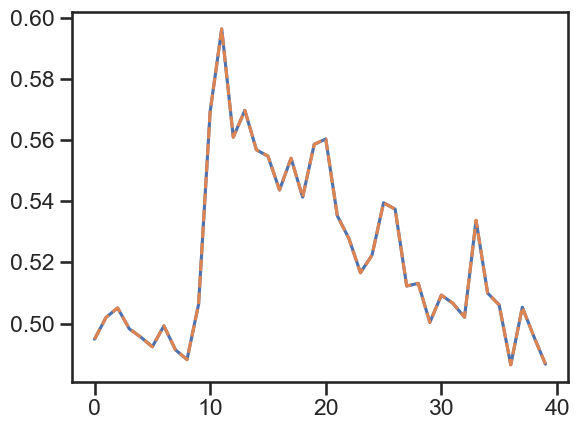

In [8]:
plt.plot(-np.mean([np.abs(results_stim['pred_err'][i]).mean(axis=0) for i in range(len(results_stim['pred_err']))], axis=0) + 1)
plt.plot(np.mean([results_stim['acc'][i].mean(axis=0) for i in range(len(results_stim['acc']))], axis=0), ls='--')

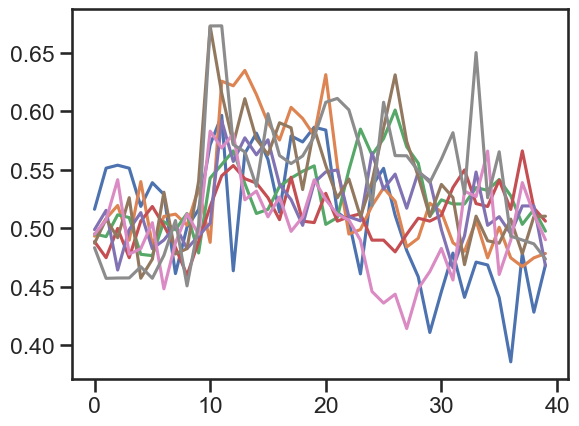

In [34]:
for _ in range(len(ephys_ids)):
    plt.plot(results_stim['acc'][_].mean(axis=0))

In [37]:
bins = np.load(folder_parent / ephys_ids[0] / 'bins.npy')
all_psth = np.load(folder_parent / ephys_ids[0] / 'all_psth.npy')
test = epoch_cross_decoder_split(bins, behavior[0].Hit, 'stim', all_psth, behavior[0].Side)

epoch_cross_decoder_split took 325.47 seconds to run


Could not connect to 127.0.0.1: 64221
Traceback (most recent call last):
  File "C:\Program Files\JetBrains\PyCharm 2023.1.2\plugins\python\helpers\pydev\_pydevd_bundle\pydevd_comm.py", line 463, in start_client
    s.connect((host, port))
ConnectionRefusedError: [WinError 10061] No connection could be made because the target machine actively refused it
Traceback (most recent call last):
  File "C:\Program Files\JetBrains\PyCharm 2023.1.2\plugins\python\helpers-pro\jupyter_debug\pydev_jupyter_utils.py", line 81, in attach_to_debugger
    debugger.connect(pydev_localhost.get_localhost(), debugger_port)
  File "C:\Program Files\JetBrains\PyCharm 2023.1.2\plugins\python\helpers\pydev\pydevd.py", line 660, in connect
    s = start_client(host, port)
  File "C:\Program Files\JetBrains\PyCharm 2023.1.2\plugins\python\helpers\pydev\_pydevd_bundle\pydevd_comm.py", line 463, in start_client
    s.connect((host, port))
ConnectionRefusedError: [WinError 10061] No connection could be made because 